# Linear Regression Machine Learning Project for House Price Prediction

# Problem Statement

Predict house price based on one feature

# Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Load the dataset

In [2]:
HouseDF=pd.read_csv('single_linear_regression_dataset.csv')

In [3]:
HouseDF

,sqft_living,price
0,1360,3729788
1,4272,12464877
2,3592,10352432
3,966,2855671
4,4926,14485221
...,...,...
49995,733,2889291
49996,3420,10625142
49997,2218,6982903
49998,992,2530805


# dataset understanding

In [4]:
HouseDF.shape

(50000, 2)

In [5]:
HouseDF

,sqft_living,price
0,1360,3729788
1,4272,12464877
2,3592,10352432
3,966,2855671
4,4926,14485221
...,...,...
49995,733,2889291
49996,3420,10625142
49997,2218,6982903
49998,992,2530805


In [6]:
HouseDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   sqft_living  50000 non-null  int64
 1   price        50000 non-null  int64
dtypes: int64(2)
memory usage: 781.4 KB


In [7]:
HouseDF.describe()

,sqft_living,price
count,50000.000000,5.000000e+04
mean,2752.970540,8.258799e+06
std,1297.148134,3.921711e+06
min,500.000000,-2.173550e+05
25%,1630.000000,4.889653e+06
50%,2756.000000,8.266070e+06
75%,3872.000000,1.161632e+07
max,4999.000000,1.655986e+07


# Data cleaning

In [8]:
HouseDF.isnull().sum()

sqft_living    0
price          0
dtype: int64

In [9]:
HouseDF.duplicated().sum()

0

In [10]:
HouseDF.drop_duplicates(inplace=True)

In [11]:
HouseDF.duplicated().sum()

0

# Data preprocessing

In [12]:
HouseDF.rename(columns={'sqft_living':'sqft'},inplace=True)

In [13]:
HouseDF

,sqft,price
0,1360,3729788
1,4272,12464877
2,3592,10352432
3,966,2855671
4,4926,14485221
...,...,...
49995,733,2889291
49996,3420,10625142
49997,2218,6982903
49998,992,2530805


# Visualize the data

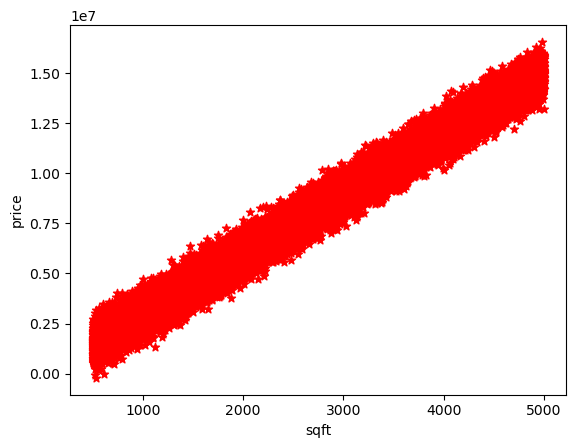

In [14]:
plt.xlabel('sqft')
plt.ylabel('price')
plt.scatter(HouseDF.sqft,HouseDF.price,color='red',marker='*')

# Define variables

In [15]:
X=HouseDF[['sqft']]
y=HouseDF['price']

# Train-Test split

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

# Train model

In [17]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X,y)

LinearRegression()

# Prediction

In [18]:
y_pred=model.predict(X_test)

In [19]:
y_pred

array([ 9482371.63890108,  6210751.83650099,  7230321.71075949, ...,
        6609583.58143152,  4978271.78261791, 13665606.85828524])

# Model Evalution

In [20]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

print('MAE:',mean_absolute_error(y_test,y_pred))
print('MSE:',mean_squared_error(y_test,y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2:',r2_score(y_test,y_pred))

MAE: 400505.2226254172
MSE: 251393118729.0232
RMSE: 501391.1833379434
R2: 0.9838487557253127


# Visualization

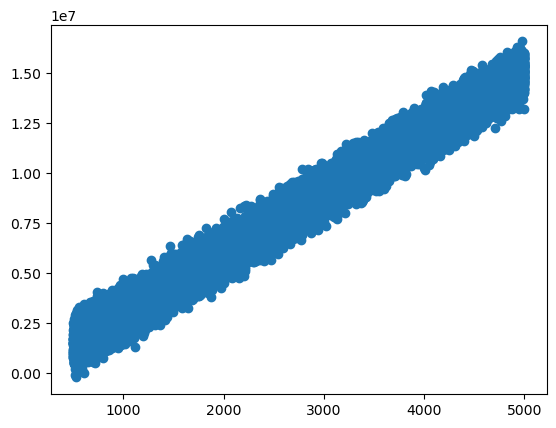

In [21]:
plt.scatter(X,y)
plt.plot(X,model.predict(X))
plt.show()

# Make your own Predition

In [22]:
x=3400
LandAreainSqRt=[[x]]
PredictedmodelResult=model.predict(LandAreainSqRt)

C:\Users\veera\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [23]:
print(PredictedmodelResult)

[10199069.28580632]


# Mannual Calculation

In [24]:
m=model.coef_
print(m)

[2998.73492429]


In [25]:
b=model.intercept_
print(b)

3370.5432212566957


In [26]:
y=m*x+b
print('The Price of {0} square feet Land is:{1}'.format(x,y[0]))

The Price of 3400 square feet Land is:10199069.285806324
